In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math

In [11]:
# import file 
FILE_PATH = ["elastic1.csv", "elastic2.csv"]
def read_csv(file_path):
    df = pd.read_csv(file_path, low_memory=False)
    return df

In [45]:
# read and concatenate the csvs then show with head()
dfs = [read_csv(path) for path in FILE_PATH]
df = pd.concat(dfs, ignore_index=True)
df.head()


,@timestamp,device_type,hostname,event,game_uuid,app_uuid,generic_string,geoip.country_code,start_time,end_time,firmware_version,software_version,@version,log_level,original.time
0,"Apr 21, 2026 @ 20:21:50.727",2,vv-0007329f8e86,GAME_END,86f138fc-e873-4d94-83cf-98cd977a23bb,a8d8e42c-5403-4160-b3d2-4a7e021254d9,PAINTSPLATTERS_UGC,US,-,"Apr 21, 2026 @ 20:21:50.727",5.19-0.0,v18.4.0,1,3,"Apr 21, 2026 @ 22:21:50.727"
1,"Apr 21, 2026 @ 20:13:32.858",2,vv-0007329f8e86,GAME_START,86f138fc-e873-4d94-83cf-98cd977a23bb,a8d8e42c-5403-4160-b3d2-4a7e021254d9,PAINTSPLATTERS_UGC,US,"Apr 21, 2026 @ 20:13:32.858",-,5.19-0.0,v18.4.0,1,3,"Apr 21, 2026 @ 22:13:32.858"
2,"Apr 21, 2026 @ 20:13:32.700",2,vv-0007329f8e86,GAME_END,784f67b3-63a8-483b-8421-5e1fbc0af755,a8d8e42c-5403-4160-b3d2-4a7e021254d9,BODY_AWARENESS,US,-,"Apr 21, 2026 @ 20:13:32.700",5.19-0.0,v18.4.0,1,3,"Apr 21, 2026 @ 22:13:32.700"
3,"Apr 21, 2026 @ 20:10:54.124",2,vv-000732a85777,GAME_END,7639a8e5-29a0-48e6-8ea4-6726896ea7ee,70b0f532-0721-4dd2-bbdb-13b03fd8c900,DINNER_PARTY,GB,-,"Apr 21, 2026 @ 20:10:54.124",6.04-0.0,v18.3.4,1,3,"Apr 21, 2026 @ 22:10:54.124"
4,"Apr 21, 2026 @ 20:08:21.253",2,vv-0007329f8e86,GAME_START,784f67b3-63a8-483b-8421-5e1fbc0af755,a8d8e42c-5403-4160-b3d2-4a7e021254d9,BODY_AWARENESS,US,"Apr 21, 2026 @ 20:08:21.253",-,5.19-0.0,v18.4.0,1,3,"Apr 21, 2026 @ 22:08:21.253"


In [ ]:
df.tail(20)

,@timestamp,device_type,hostname,event,game_uuid,app_uuid,generic_string,geoip.country_code,start_time,end_time,firmware_version,software_version,@version,log_level,original.time
561234,"Jul 14, 2023 @ 14:46:17.117",2,vv-0007329f8ea5,GAME_END,148f00e5-03b9-45dc-b8ce-4b5d93232105,fec37548-13a5-4f70-9b12-d0a0c1671696,CROSSING,DE,-,"Jul 14, 2023 @ 14:46:17.117",6.02-0.3,v17.2.0,1,3,"Jul 14, 2023 @ 16:46:17.117"
561235,"Jul 14, 2023 @ 14:37:34.247",2,vv-0007329f8ea5,GAME_START,148f00e5-03b9-45dc-b8ce-4b5d93232105,fec37548-13a5-4f70-9b12-d0a0c1671696,CROSSING,DE,"Jul 14, 2023 @ 14:37:34.247",-,6.02-0.3,v17.2.0,1,3,"Jul 14, 2023 @ 16:37:34.247"
561236,"Jul 14, 2023 @ 14:36:54.474",2,vv-0007329f8ea5,GAME_END,4981936d-5d64-4950-9f22-89a0390c9ff7,fec37548-13a5-4f70-9b12-d0a0c1671696,FISHES,DE,-,"Jul 14, 2023 @ 14:36:54.474",6.02-0.3,v17.2.0,1,3,"Jul 14, 2023 @ 16:36:54.474"
561237,"Jul 14, 2023 @ 14:35:23.523",2,vv-0007329f8ea5,GAME_START,4981936d-5d64-4950-9f22-89a0390c9ff7,fec37548-13a5-4f70-9b12-d0a0c1671696,FISHES,DE,"Jul 14, 2023 @ 14:35:23.523",-,6.02-0.3,v17.2.0,1,3,"Jul 14, 2023 @ 16:35:23.523"
561238,"Jul 14, 2023 @ 09:54:55.805",2,vv-0007329f8ea5,GAME_START,1d72bfd7-7c11-43c9-8991-504d46108584,f46e414a-1081-41a4-a6e2-35bd8a5cd335,FLOWERS,DE,"Jul 14, 2023 @ 09:54:55.805",-,6.02-0.3,v17.2.0,1,3,"Jul 14, 2023 @ 11:54:55.805"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
561429,"Jun 1, 2023 @ 09:39:05.839",2,vv-000732a3e9b2,GAME_START,4d9f8ba0-07a9-4066-a2d0-d68afb1839f2,8ec6e629-4a3f-4028-8284-00db4cab91e9,LEAVES,NL,"Jun 1, 2023 @ 09:39:05.839",-,6.02-0.3,v17.1.0,1,3,"Jun 1, 2023 @ 11:39:05.839"
561430,"Jun 1, 2023 @ 09:38:55.601",2,vv-000732a3e9b2,GAME_END,05a33030-1b8d-474e-a5f5-26ef04df7285,8ec6e629-4a3f-4028-8284-00db4cab91e9,LEAVES,NL,-,"Jun 1, 2023 @ 09:38:55.601",6.02-0.3,v17.1.0,1,3,"Jun 1, 2023 @ 11:38:55.601"
561431,"Jun 1, 2023 @ 09:38:38.855",2,vv-000732a3e9b2,GAME_START,05a33030-1b8d-474e-a5f5-26ef04df7285,8ec6e629-4a3f-4028-8284-00db4cab91e9,LEAVES,NL,"Jun 1, 2023 @ 09:38:38.855",-,6.02-0.3,v17.1.0,1,3,"Jun 1, 2023 @ 11:38:38.855"
561432,"May 25, 2023 @ 13:22:21.589",2,vv-000732a3ea57,GAME_END,33fd7dea-9862-4bfe-b5bb-29fc71bc1a3c,51ddaf25-4e73-40b6-b984-1bba6fbc420e,LEAVES,NL,-,"May 25, 2023 @ 13:22:21.589",6.02-0.3,v17.1.0,1,3,"May 25, 2023 @ 15:22:21.589"


In [13]:
df.shape

(561434, 15)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 561434 entries, 0 to 561433
Data columns (total 15 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   @timestamp          561434 non-null  object
 1   device_type         561434 non-null  object
 2   hostname            561434 non-null  object
 3   event               561434 non-null  object
 4   game_uuid           561434 non-null  object
 5   app_uuid            561434 non-null  object
 6   generic_string      561434 non-null  object
 7   geoip.country_code  561434 non-null  object
 8   start_time          561434 non-null  object
 9   end_time            561434 non-null  object
 10  firmware_version    561434 non-null  object
 11  software_version    561434 non-null  object
 12  @version            561434 non-null  int64 
 13  log_level           561434 non-null  object
 14  original.time       561434 non-null  object
dtypes: int64(1), object(14)
memory usage: 64.3+ MB


In [15]:
df_query = df.copy(deep=True)

In [16]:
# datetime conversion and sanity check
print("Total rows before:", len(df_query))

clean_timestamps = df_query['@timestamp'].str.replace(' @ ', ' ')
clean_localtime = df_query['original.time'].str.replace(' @ ', ' ')

df_query['@timestamp'] = pd.to_datetime(clean_timestamps, errors='coerce')
df_query['original.time'] = pd.to_datetime(clean_localtime, errors='coerce')

missing_dates = df_query['@timestamp'].isna().sum()
print(f"Dates that failed to parse: {missing_dates}")

df_query = df_query.dropna(subset=['@timestamp'])
print("Total rows after:", len(df_query))

Total rows before: 561434
Dates that failed to parse: 0
Total rows after: 561434


In [17]:
df_query['date'] = df_query['@timestamp'].dt.date
df_query['time'] = df_query['@timestamp'].dt.time

In [18]:
# get first entry per device to determine activation date
activation_dates = df_query.groupby('hostname')['date'].min().reset_index()
activation_dates = activation_dates.rename(columns={'date': 'activation_date'})

df_query = df_query.merge(activation_dates, on='hostname', how='left')
df_query.head()

,@timestamp,device_type,hostname,event,game_uuid,app_uuid,generic_string,geoip.country_code,start_time,end_time,firmware_version,software_version,@version,log_level,original.time,date,time,activation_date
0,2026-04-21 20:21:50.727,2,vv-0007329f8e86,GAME_END,86f138fc-e873-4d94-83cf-98cd977a23bb,a8d8e42c-5403-4160-b3d2-4a7e021254d9,PAINTSPLATTERS_UGC,US,-,"Apr 21, 2026 @ 20:21:50.727",5.19-0.0,v18.4.0,1,3,2026-04-21 22:21:50.727,2026-04-21,20:21:50.727000,2026-03-06
1,2026-04-21 20:13:32.858,2,vv-0007329f8e86,GAME_START,86f138fc-e873-4d94-83cf-98cd977a23bb,a8d8e42c-5403-4160-b3d2-4a7e021254d9,PAINTSPLATTERS_UGC,US,"Apr 21, 2026 @ 20:13:32.858",-,5.19-0.0,v18.4.0,1,3,2026-04-21 22:13:32.858,2026-04-21,20:13:32.858000,2026-03-06
2,2026-04-21 20:13:32.700,2,vv-0007329f8e86,GAME_END,784f67b3-63a8-483b-8421-5e1fbc0af755,a8d8e42c-5403-4160-b3d2-4a7e021254d9,BODY_AWARENESS,US,-,"Apr 21, 2026 @ 20:13:32.700",5.19-0.0,v18.4.0,1,3,2026-04-21 22:13:32.700,2026-04-21,20:13:32.700000,2026-03-06
3,2026-04-21 20:10:54.124,2,vv-000732a85777,GAME_END,7639a8e5-29a0-48e6-8ea4-6726896ea7ee,70b0f532-0721-4dd2-bbdb-13b03fd8c900,DINNER_PARTY,GB,-,"Apr 21, 2026 @ 20:10:54.124",6.04-0.0,v18.3.4,1,3,2026-04-21 22:10:54.124,2026-04-21,20:10:54.124000,2026-03-06
4,2026-04-21 20:08:21.253,2,vv-0007329f8e86,GAME_START,784f67b3-63a8-483b-8421-5e1fbc0af755,a8d8e42c-5403-4160-b3d2-4a7e021254d9,BODY_AWARENESS,US,"Apr 21, 2026 @ 20:08:21.253",-,5.19-0.0,v18.4.0,1,3,2026-04-21 22:08:21.253,2026-04-21,20:08:21.253000,2026-03-06


In [19]:
df_query['device_type'] = pd.to_numeric(df_query['device_type'], errors='coerce')

In [20]:
df_query['date'] = pd.to_datetime(df_query['date'])
df_query['activation_date'] = pd.to_datetime(df_query['activation_date'])

df_query['days_since_activation'] = (df_query['date'] - df_query['activation_date']).dt.days

print(df_query[['hostname', 'date', 'activation_date', 'days_since_activation']].head(10))

          hostname       date activation_date  days_since_activation
0  vv-0007329f8e86 2026-04-21      2026-03-06                     46
1  vv-0007329f8e86 2026-04-21      2026-03-06                     46
2  vv-0007329f8e86 2026-04-21      2026-03-06                     46
3  vv-000732a85777 2026-04-21      2026-03-06                     46
4  vv-0007329f8e86 2026-04-21      2026-03-06                     46
5  vv-0007329f8e86 2026-04-21      2026-03-06                     46
6  vv-0007328953cb 2026-04-21      2026-01-13                     98
7  vv-0007328953cb 2026-04-21      2026-01-13                     98
8  vv-0007329f8e86 2026-04-21      2026-03-06                     46
9  vv-0007329f8e86 2026-04-21      2026-03-06                     46


In [21]:
print(df_query['activation_date'].value_counts())

activation_date
2025-12-03    66999
2025-11-25    39693
2026-03-05    30218
2023-09-29    23467
2025-11-30    17014
              ...  
2025-10-17        2
2024-06-09        2
2025-09-25        1
2024-05-06        1
2023-11-13        1
Name: count, Length: 256, dtype: int64


In [22]:
day_zero_events = df_query[df_query['days_since_activation'] == 0]
print(day_zero_events[['hostname', 'date', 'event', 'generic_string', 'activation_date', 'days_since_activation']].head(10))

           hostname       date       event  generic_string activation_date  \
72  vv-000732a8552a 2026-04-21  GAME_START   TOOTHBRUSHING      2026-04-21   
73  vv-000732a8552a 2026-04-21    GAME_END  BODY_AWARENESS      2026-04-21   
76  vv-000732a8552a 2026-04-21  GAME_START  BODY_AWARENESS      2026-04-21   
77  vv-000732a8552a 2026-04-21    GAME_END      BUBBLES_UP      2026-04-21   
78  vv-000732a8552a 2026-04-21  GAME_START      BUBBLES_UP      2026-04-21   
79  vv-000732a8552a 2026-04-21    GAME_END    BEACHCOMBING      2026-04-21   
82  vv-000732a8552a 2026-04-21  GAME_START    BEACHCOMBING      2026-04-21   
83  vv-000732a8552a 2026-04-21    GAME_END          MEMORY      2026-04-21   
84  vv-000732a8552a 2026-04-21  GAME_START          MEMORY      2026-04-21   
85  vv-000732a8552a 2026-04-21    GAME_END       TRAINS_UP      2026-04-21   

    days_since_activation  
72                      0  
73                      0  
76                      0  
77                      0  
7

**<h4>Daily usage trends</h4>**

In [23]:
# look at each time a game session is started
df_games = df_query[df_query['event'] == 'GAME_START'].copy()

df_games['local_hour'] = df_games['original.time'].dt.hour

time_of_day_trend = df_games.groupby('local_hour').size().reset_index(name='total_games_played')

print("Busiest hours for usage:")
print(time_of_day_trend.sort_values(by='total_games_played', ascending=False))

Busiest hours for usage:
    local_hour  total_games_played
23          23               15115
21          21               14533
16          16               14195
20          20               13830
19          19               13780
22          22               13575
17          17               13413
0            0               13081
18          18               12559
5            5               12468
6            6               12309
1            1               12289
15          15               11919
7            7               11663
8            8               11053
4            4               10168
14          14               10127
2            2                9869
12          12                9654
11          11                9644
13          13                9372
9            9                9120
10          10                9058
3            3                8111


<h3>Localized Time</h3>

In [24]:
import pytz

df_query['@timestamp'] = pd.to_datetime(df_query['@timestamp'], errors='coerce', utc=True)

def get_local_time(row):
    country_code = row['geoip.country_code']
    utc_time = row['@timestamp']
    
    if pd.isna(country_code) or pd.isna(utc_time):
        return np.nan 
        
    try:
        tz_string = pytz.country_timezones[country_code][0]
        local_tz = pytz.timezone(tz_string)
        local_time = utc_time.astimezone(local_tz)
        return local_time.strftime('%H:%M:%S')
        
    except KeyError:
        return utc_time.strftime('%H:%M:%S')

df_query['local_time'] = df_query.apply(get_local_time, axis=1)

print(df_query[['@timestamp', 'geoip.country_code', 'local_time']].head())

df_games['@timestamp'] = pd.to_datetime(df_games['@timestamp'], errors='coerce', utc=True)
df_games['local_time'] = df_games.apply(get_local_time, axis=1)
df_games['local_hour'] = df_games['local_time'].str.slice(0, 2).astype(float)


                        @timestamp geoip.country_code local_time
0 2026-04-21 20:21:50.727000+00:00                 US   16:21:50
1 2026-04-21 20:13:32.858000+00:00                 US   16:13:32
2 2026-04-21 20:13:32.700000+00:00                 US   16:13:32
3 2026-04-21 20:10:54.124000+00:00                 GB   21:10:54
4 2026-04-21 20:08:21.253000+00:00                 US   16:08:21


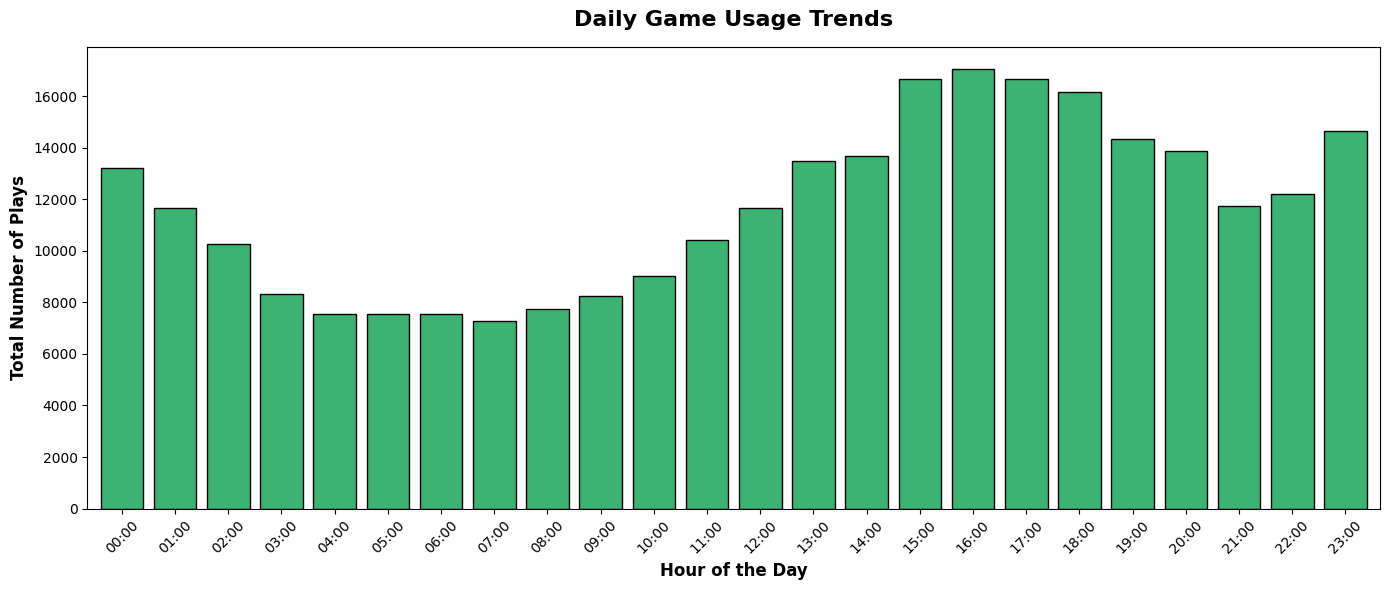

In [25]:
hourly_counts = df_games['local_hour'].value_counts().sort_index()
plt.figure(figsize=(14, 6))
hourly_counts.plot(kind='bar', color='mediumseagreen', edgecolor='black', width=0.8)
plt.title('Daily Game Usage Trends', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Hour of the Day', fontsize=12, fontweight='bold')
plt.ylabel('Total Number of Plays', fontsize=12, fontweight='bold')
hours_present = hourly_counts.index.astype(int)
plt.xticks(
    ticks=range(len(hours_present)), 
    labels=[f"{h:02d}:00" for h in hours_present], 
    rotation=45
)
plt.tight_layout()
plt.show()

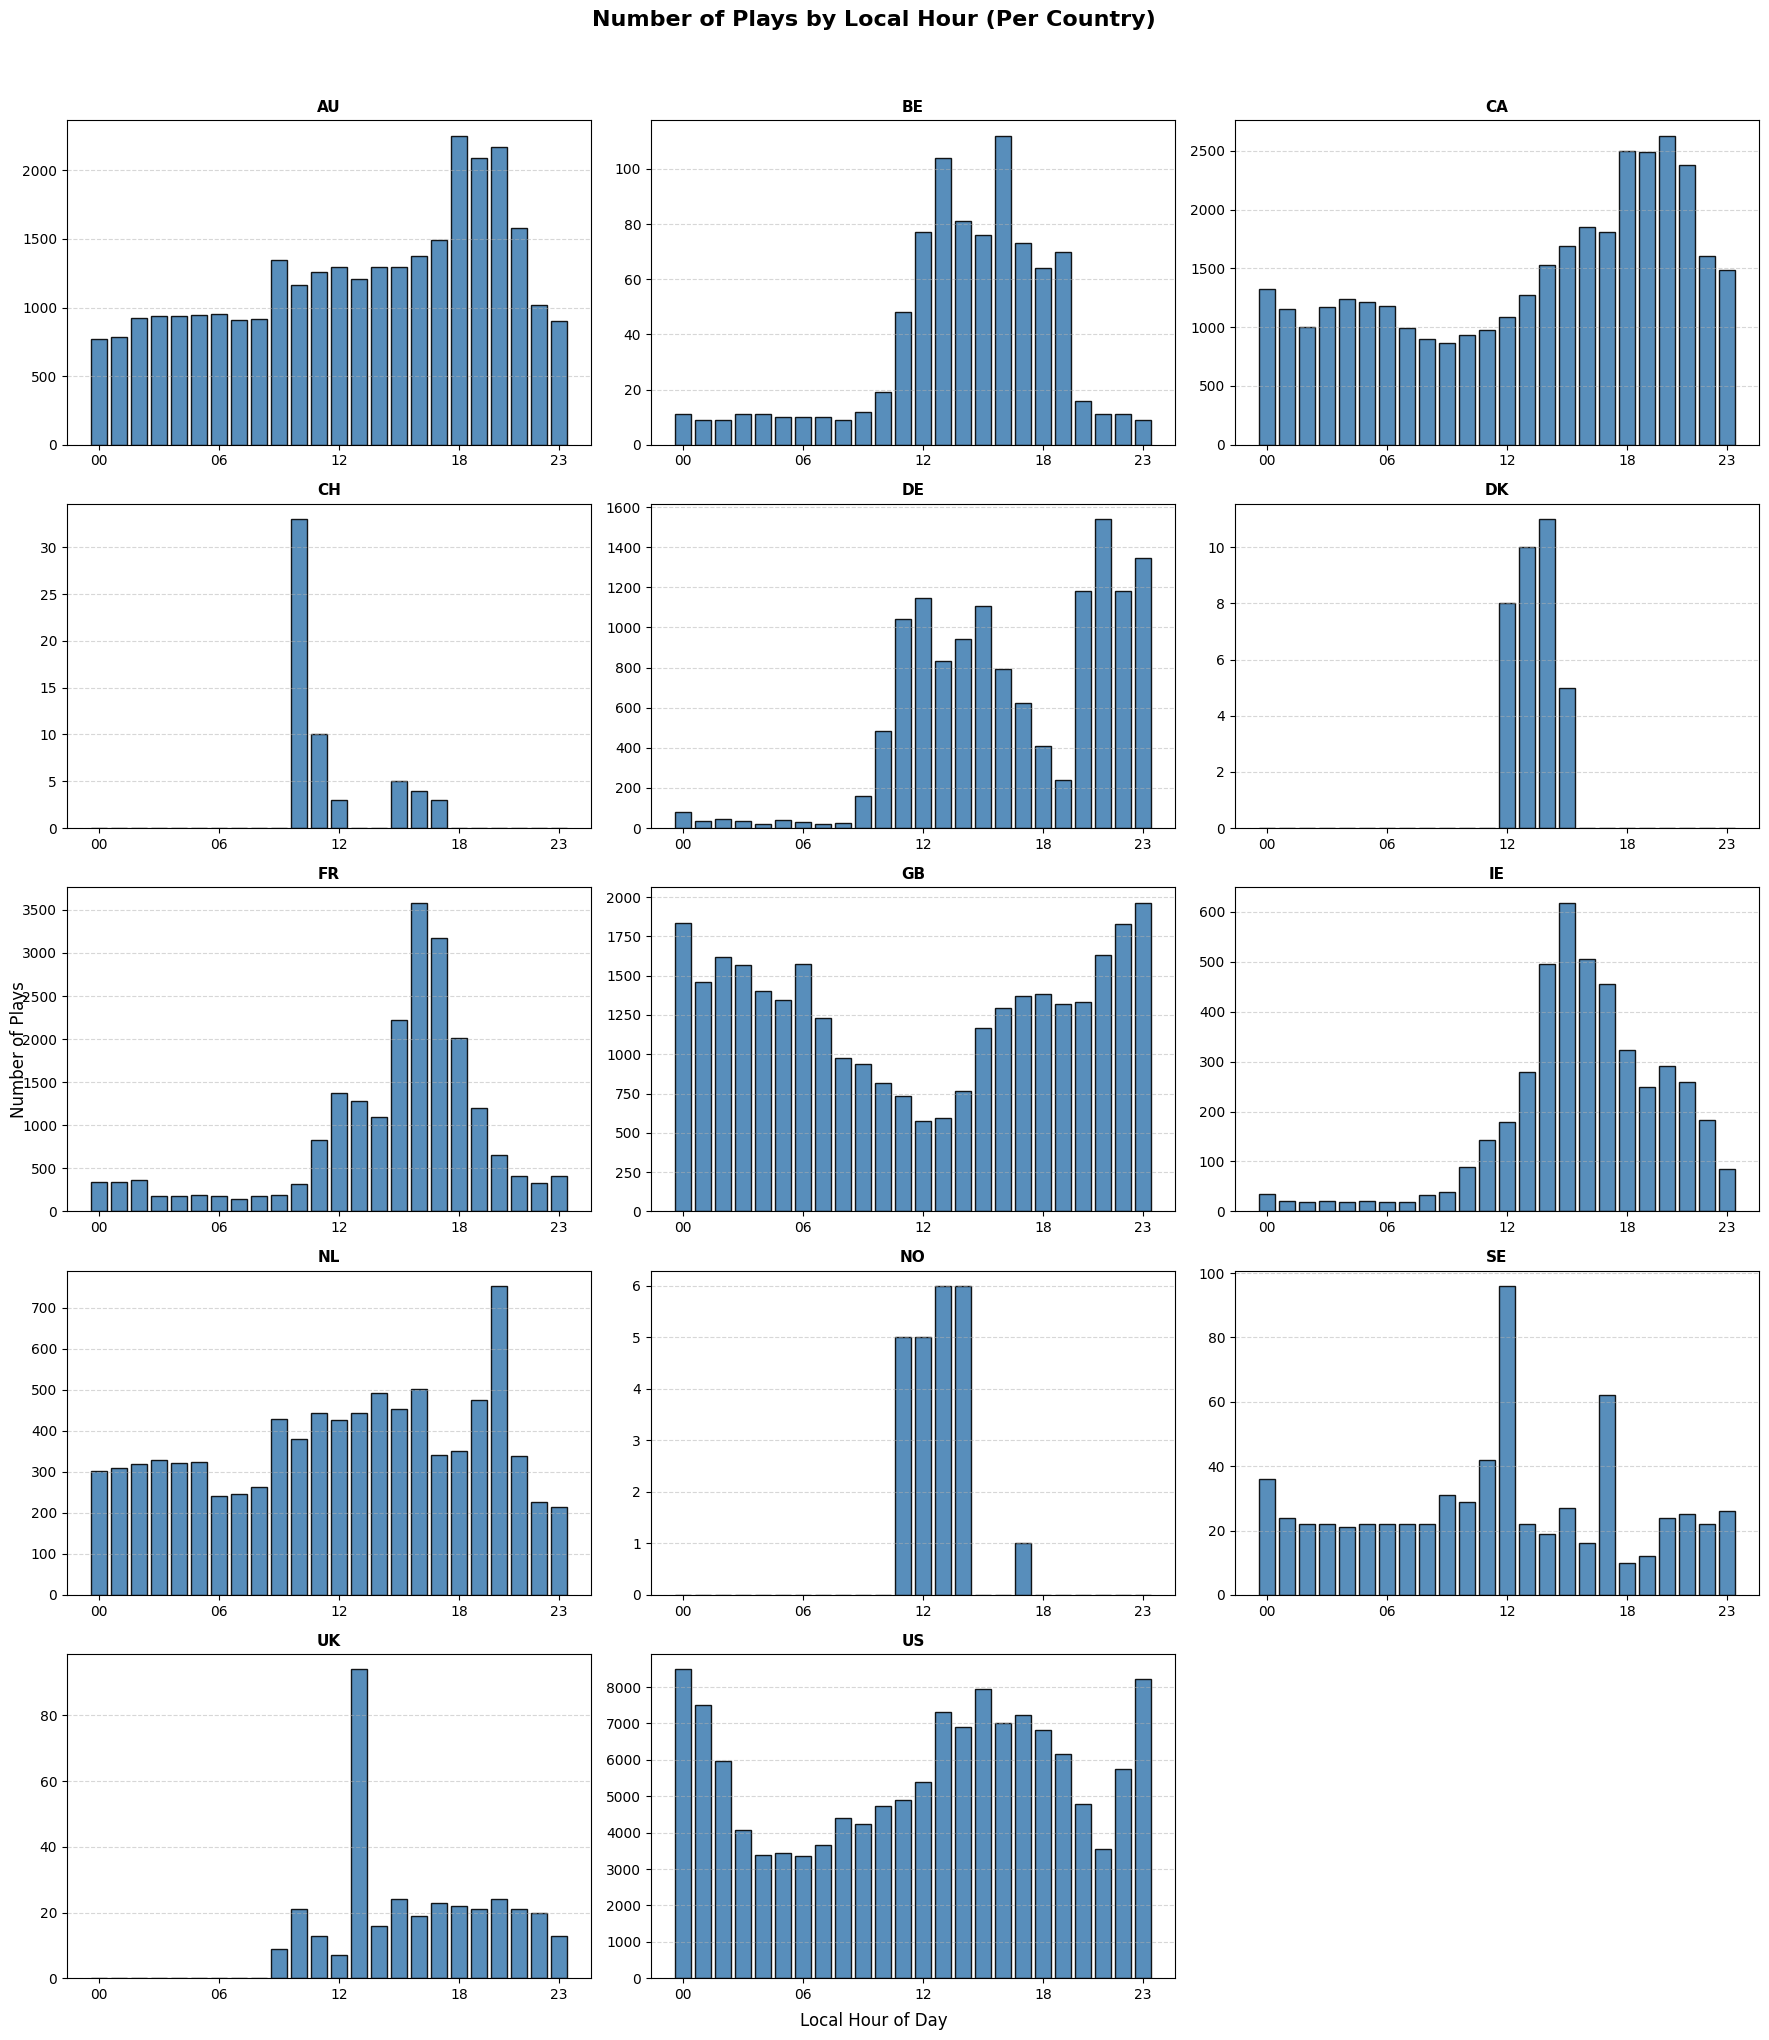

In [26]:
# Per-country hourly play distribution using local time
df_country_hour = df_games.copy()
df_country_hour = df_country_hour[df_country_hour['geoip.country_code'].notna()]
df_country_hour = df_country_hour[df_country_hour['geoip.country_code'] != '-']

# Ensure hour is valid integer from 0 to 23
df_country_hour['local_hour'] = pd.to_numeric(df_country_hour['local_hour'], errors='coerce')
df_country_hour = df_country_hour.dropna(subset=['local_hour'])
df_country_hour['local_hour'] = df_country_hour['local_hour'].astype(int)
df_country_hour = df_country_hour[(df_country_hour['local_hour'] >= 0) & (df_country_hour['local_hour'] <= 23)]

country_hourly = (
    df_country_hour
    .groupby(['geoip.country_code', 'local_hour'])
    .size()
    .reset_index(name='plays')
)

countries = sorted(country_hourly['geoip.country_code'].unique())
cols = 3
rows = int(np.ceil(len(countries) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(18, 4 * rows))
axes = np.array(axes).reshape(-1)

for i, country in enumerate(countries):
    ax = axes[i]
    country_data = country_hourly[country_hourly['geoip.country_code'] == country].set_index('local_hour')['plays']
    country_data = country_data.reindex(range(24), fill_value=0)

    ax.bar(range(24), country_data.values, color='steelblue', edgecolor='black', alpha=0.9)
    ax.set_title(f'{country}', fontsize=11, fontweight='bold')
    ax.set_xticks([0, 6, 12, 18, 23])
    ax.set_xticklabels(['00', '06', '12', '18', '23'])
    ax.grid(axis='y', linestyle='--', alpha=0.5)

for j in range(len(countries), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Number of Plays by Local Hour (Per Country)', fontsize=16, fontweight='bold', y=1.02)
fig.supxlabel('Local Hour of Day')
fig.supylabel('Number of Plays')
plt.tight_layout()
plt.show()

<h3>Seasonal Trend</h3>

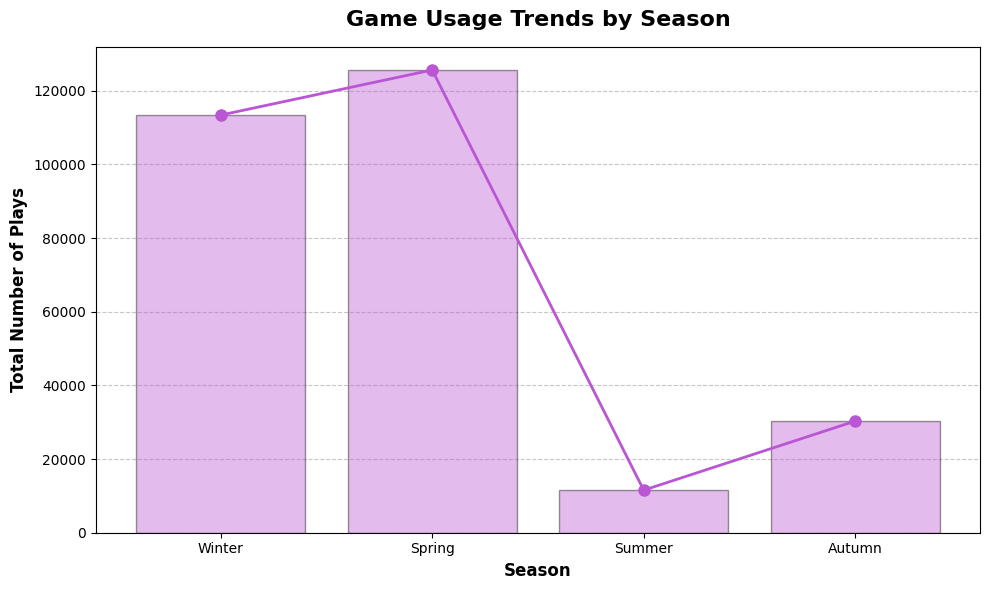

In [27]:

month_to_season = {
    1: 'Winter', 2: 'Winter', 3: 'Spring', 
    4: 'Spring', 5: 'Spring', 6: 'Summer', 
    7: 'Summer', 8: 'Summer', 9: 'Autumn', 
    10: 'Autumn', 11: 'Autumn', 12: 'Winter'
}

df_games['season'] = df_games['@timestamp'].dt.month.map(month_to_season)

season_order = ['Winter', 'Spring', 'Summer', 'Autumn']
df_games['season'] = pd.Categorical(df_games['season'], categories=season_order, ordered=True)

seasonal_counts = df_games['season'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
plt.plot(seasonal_counts.index, seasonal_counts.values, color='mediumorchid', marker='o', linestyle='-', linewidth=2, markersize=8, zorder=3)
plt.bar(seasonal_counts.index, seasonal_counts.values, color='mediumorchid', alpha=0.4, edgecolor='black', zorder=2)
plt.title('Game Usage Trends by Season', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Season', fontsize=12, fontweight='bold')
plt.ylabel('Total Number of Plays', fontsize=12, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7, zorder=1)
plt.ylim(bottom=0)
plt.tight_layout()
plt.show()

<h3>Session Durations</h3>

In [28]:
df_sorted = df_query.sort_values(['game_uuid', '@timestamp'])

starts_ends = df_sorted[df_sorted['event'].isin(['GAME_START', 'GAME_END'])].copy()

starts_ends['next_event'] = starts_ends.groupby('game_uuid')['event'].shift(-1)
starts_ends['next_timestamp'] = starts_ends.groupby('game_uuid')['@timestamp'].shift(-1)

valid_sessions = starts_ends[
    (starts_ends['event'] == 'GAME_START') & 
    (starts_ends['next_event'] == 'GAME_END')
].copy()

valid_sessions['duration_minutes'] = (valid_sessions['next_timestamp'] - valid_sessions['@timestamp']).dt.total_seconds() / 60

df_sessions = valid_sessions[['game_uuid', 'generic_string', '@timestamp', 'next_timestamp', 'duration_minutes']].copy()
df_sessions.rename(columns={'@timestamp': 'session_start', 'next_timestamp': 'session_end'}, inplace=True)

print(f"Total valid sessions found: {len(df_sessions)}")
display(df_sessions.head())

Total valid sessions found: 173182


,game_uuid,generic_string,session_start,session_end,duration_minutes
128618,0000b024-2d60-4622-9a18-1ef50c8c066d,ANEMONES,2026-03-21 14:38:41.878000+00:00,2026-03-21 14:43:46.965000+00:00,5.084783
491846,0000c8e1-386c-47cc-86e7-da051ca33127,BUBBLES_UP,2025-05-31 13:39:28.311000+00:00,2025-05-31 13:39:51.627000+00:00,0.388600
68185,0000eab7-f499-46d2-9ec2-062cefc0ff04,BIRDFEEDER,2026-04-02 01:22:31.526000+00:00,2026-04-02 01:27:43.966000+00:00,5.207333
316556,00014530-c359-4110-a5c3-bb16e2074687,BUTTERFLIES,2025-12-23 05:32:21.630000+00:00,2025-12-23 05:37:26.074000+00:00,5.074067
446192,0001d2af-4c2a-431b-9d78-7349c8ab5298,LEAVES,2025-11-27 13:52:27.780000+00:00,2025-11-27 13:57:38.944000+00:00,5.186067


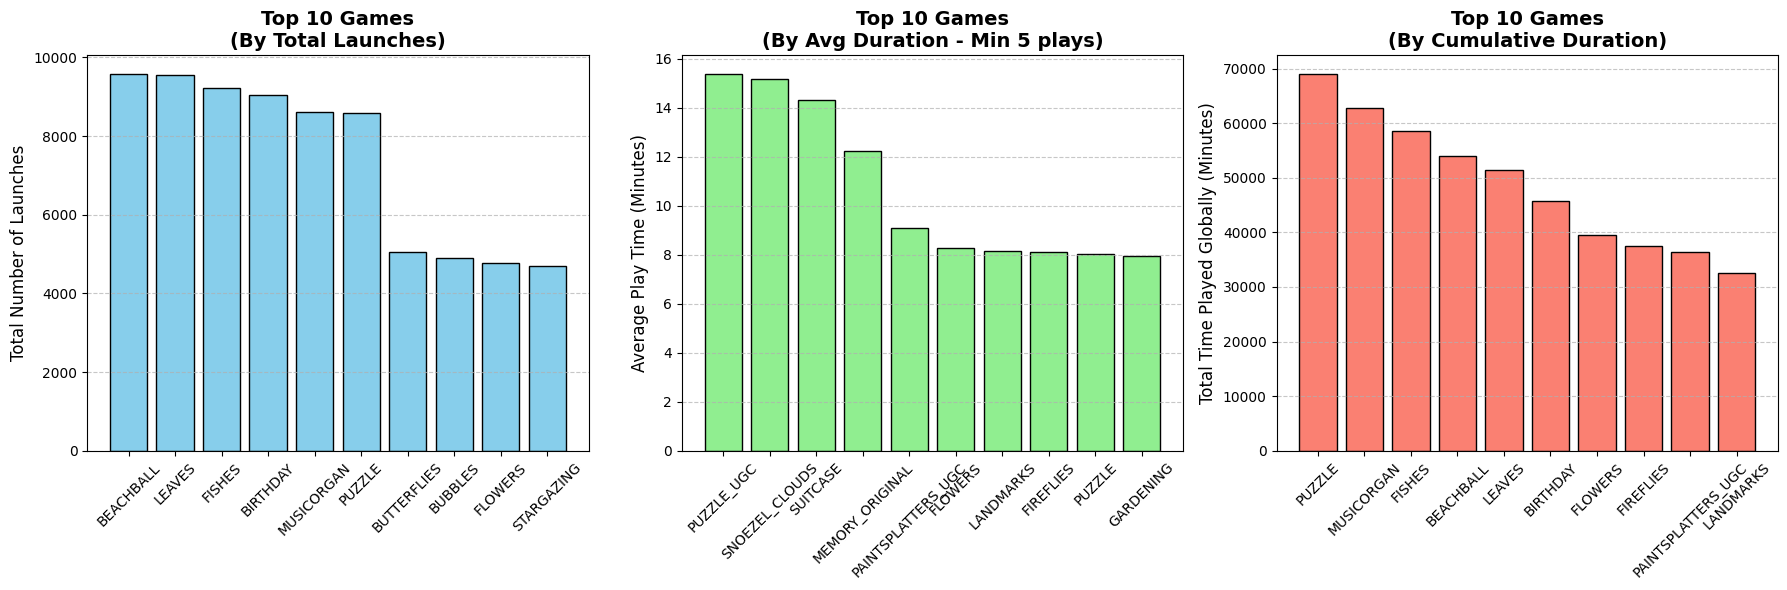

In [29]:
global_stats = df_sessions.groupby('generic_string').agg(
    total_launches=('game_uuid', 'count'),          # Number of times launched
    avg_duration=('duration_minutes', 'mean'),      # Average session duration
    total_duration=('duration_minutes', 'sum')      # Cumulative session duration
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

top_launches = global_stats.sort_values('total_launches', ascending=False).head(10)
axes[0].bar(top_launches['generic_string'], top_launches['total_launches'], color='skyblue', edgecolor='black')
axes[0].set_title('Top 10 Games\n(By Total Launches)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Total Number of Launches', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

valid_avg_games = global_stats[global_stats['total_launches'] >= 5] 
top_avg = valid_avg_games.sort_values('avg_duration', ascending=False).head(10)
axes[1].bar(top_avg['generic_string'], top_avg['avg_duration'], color='lightgreen', edgecolor='black')
axes[1].set_title('Top 10 Games\n(By Avg Duration - Min 5 plays)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Average Play Time (Minutes)', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

top_cumulative = global_stats.sort_values('total_duration', ascending=False).head(10)
axes[2].bar(top_cumulative['generic_string'], top_cumulative['total_duration'], color='salmon', edgecolor='black')
axes[2].set_title('Top 10 Games\n(By Cumulative Duration)', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Total Time Played Globally (Minutes)', fontsize=12)
axes[2].tick_params(axis='x', rotation=45)

for ax in axes:
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    
plt.tight_layout()
plt.show()

**<h4>Usage trend since activation</h4>**

In [30]:
daily_usage = df_games.groupby(['hostname', 'days_since_activation']).size().reset_index(name='games_played')

print("\nDaily game counts per device:")
print(daily_usage.head(10))

consistency_check = daily_usage.groupby('hostname')['days_since_activation'].nunique().reset_index(name='total_active_days')

print("\nTotal days each device was active:")
print(consistency_check.head())


Daily game counts per device:
          hostname  days_since_activation  games_played
0  hol1c1b0d97884a                      0             8
1  hol1c1b0d97884a                      1            22
2  hol408d5c128ce8                      0            53
3  hol408d5c128ce8                     34            29
4  hol408d5ce3b16b                      0            27
5  hol408d5ce3c5d9                      0            11
6  holb42e99393b27                      0            31
7  holb42e99586d00                      0            25
8  holb42e99b77b83                      0             8
9  holb42e99b77b83                      1            18

Total days each device was active:
          hostname  total_active_days
0  hol1c1b0d97884a                  2
1  hol408d5c128ce8                  2
2  hol408d5ce3b16b                  1
3  hol408d5ce3c5d9                  1
4  holb42e99393b27                  1


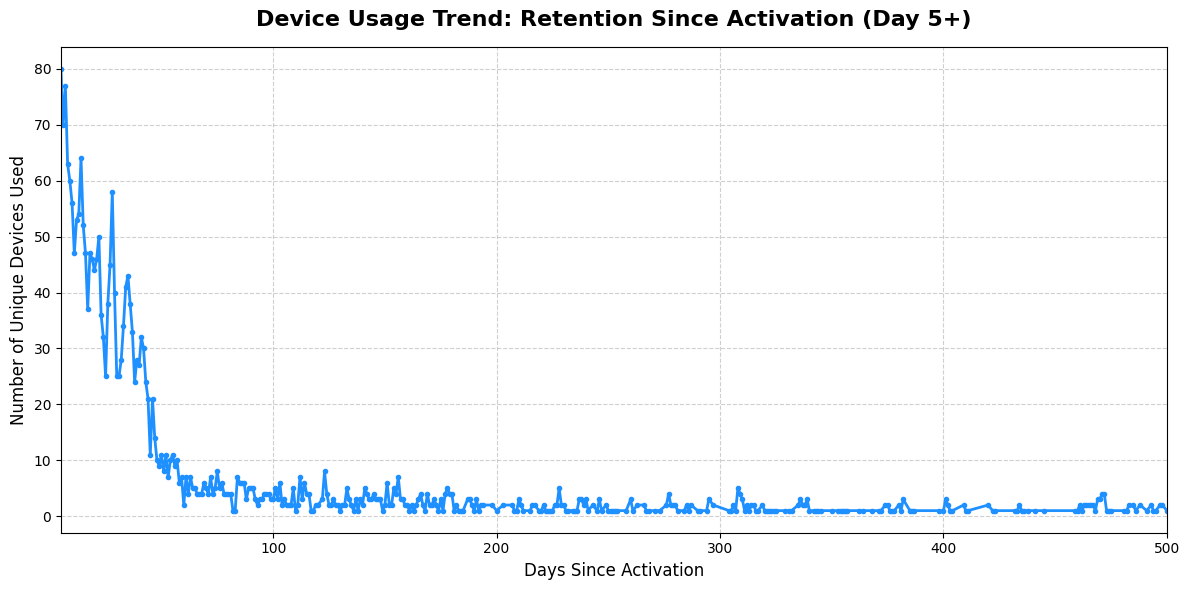

In [31]:
# Group by the days since activation and count how many UNIQUE devices were active
daily_retention = df_query.groupby('days_since_activation')['hostname'].nunique().reset_index(name='unique_devices')

daily_retention = daily_retention.sort_values('days_since_activation')
daily_retention_plot = daily_retention[daily_retention['days_since_activation'] >= 5]

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(daily_retention_plot['days_since_activation'], daily_retention_plot['unique_devices'], marker='.', linestyle='-', color='dodgerblue', linewidth=2)
ax.set_title('Device Usage Trend: Retention Since Activation (Day 5+)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Days Since Activation', fontsize=12)
ax.set_ylabel('Number of Unique Devices Used', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)
ax.set_xlim(left=5, right=500)

plt.tight_layout()
plt.show()

In [32]:
daily_games = df_games.groupby(['days_since_activation', 'generic_string']).size().reset_index(name='play_count')
daily_games = daily_games.sort_values(['days_since_activation', 'play_count'], ascending=[True, False])

top_game_per_day = daily_games.drop_duplicates(subset=['days_since_activation'])

print("--- #1 Game Played per Day Since Activation ---")
print(top_game_per_day.head(15))

--- #1 Game Played per Day Since Activation ---
      days_since_activation           generic_string  play_count
60                        0                   LEAVES        2600
155                       1                BEACHBALL        2039
302                       2                   FISHES         525
380                       3                BEACHBALL         151
513                       4                   LEAVES         219
590                       5  CONFETTI_PARTY_ORIGINAL         374
735                       6               MUSICORGAN         162
799                       7                 BIRTHDAY         133
950                       8                   LEAVES         132
1092                      9             SPINNINGTOPS         350
1142                     10                FIREFLIES         282
1240                     11                   FISHES         219
1370                     12       PAINTSPLATTERS_UGC         365
1419                     13               

**<h4>Popular games by device type</h4>**

In [33]:
df_games['device_type'].value_counts()

device_type
2.0    154285
0.0    117204
3.0      6036
5.0      3138
4.0       242
Name: count, dtype: int64

In [34]:
games_per_device_type = df_games.groupby(['device_type', 'generic_string']).size().reset_index(name='play_count')

games_per_device_type = games_per_device_type.sort_values(['device_type', 'play_count'], ascending=[True, False])

print("--- Most Popular Games per Device Type ---")
print(games_per_device_type.groupby('device_type').head(5))

--- Most Popular Games per Device Type ---
     device_type  generic_string  play_count
10           0.0       BEACHBALL        5870
57           0.0          LEAVES        5791
43           0.0          FISHES        5484
13           0.0      BIRDFEEDER        4314
54           0.0           KITES        4278
199          2.0          LEAVES        8611
148          2.0       BEACHBALL        8551
184          2.0          FISHES        8253
152          2.0        BIRTHDAY        8193
226          2.0          PUZZLE        7908
293          3.0         BUBBLES         235
275          3.0        ANEMONES         232
296          3.0     BUTTERFLIES         231
317          3.0         FLOWERS         230
329          3.0          LEAVES         230
410          4.0          FISHES          13
444          4.0      TOVER_PETS          13
438          4.0   SNOEZEL_STARS          12
406          4.0     BUTTERFLIES          11
423          4.0  PAINTSPLATTERS          10
482         

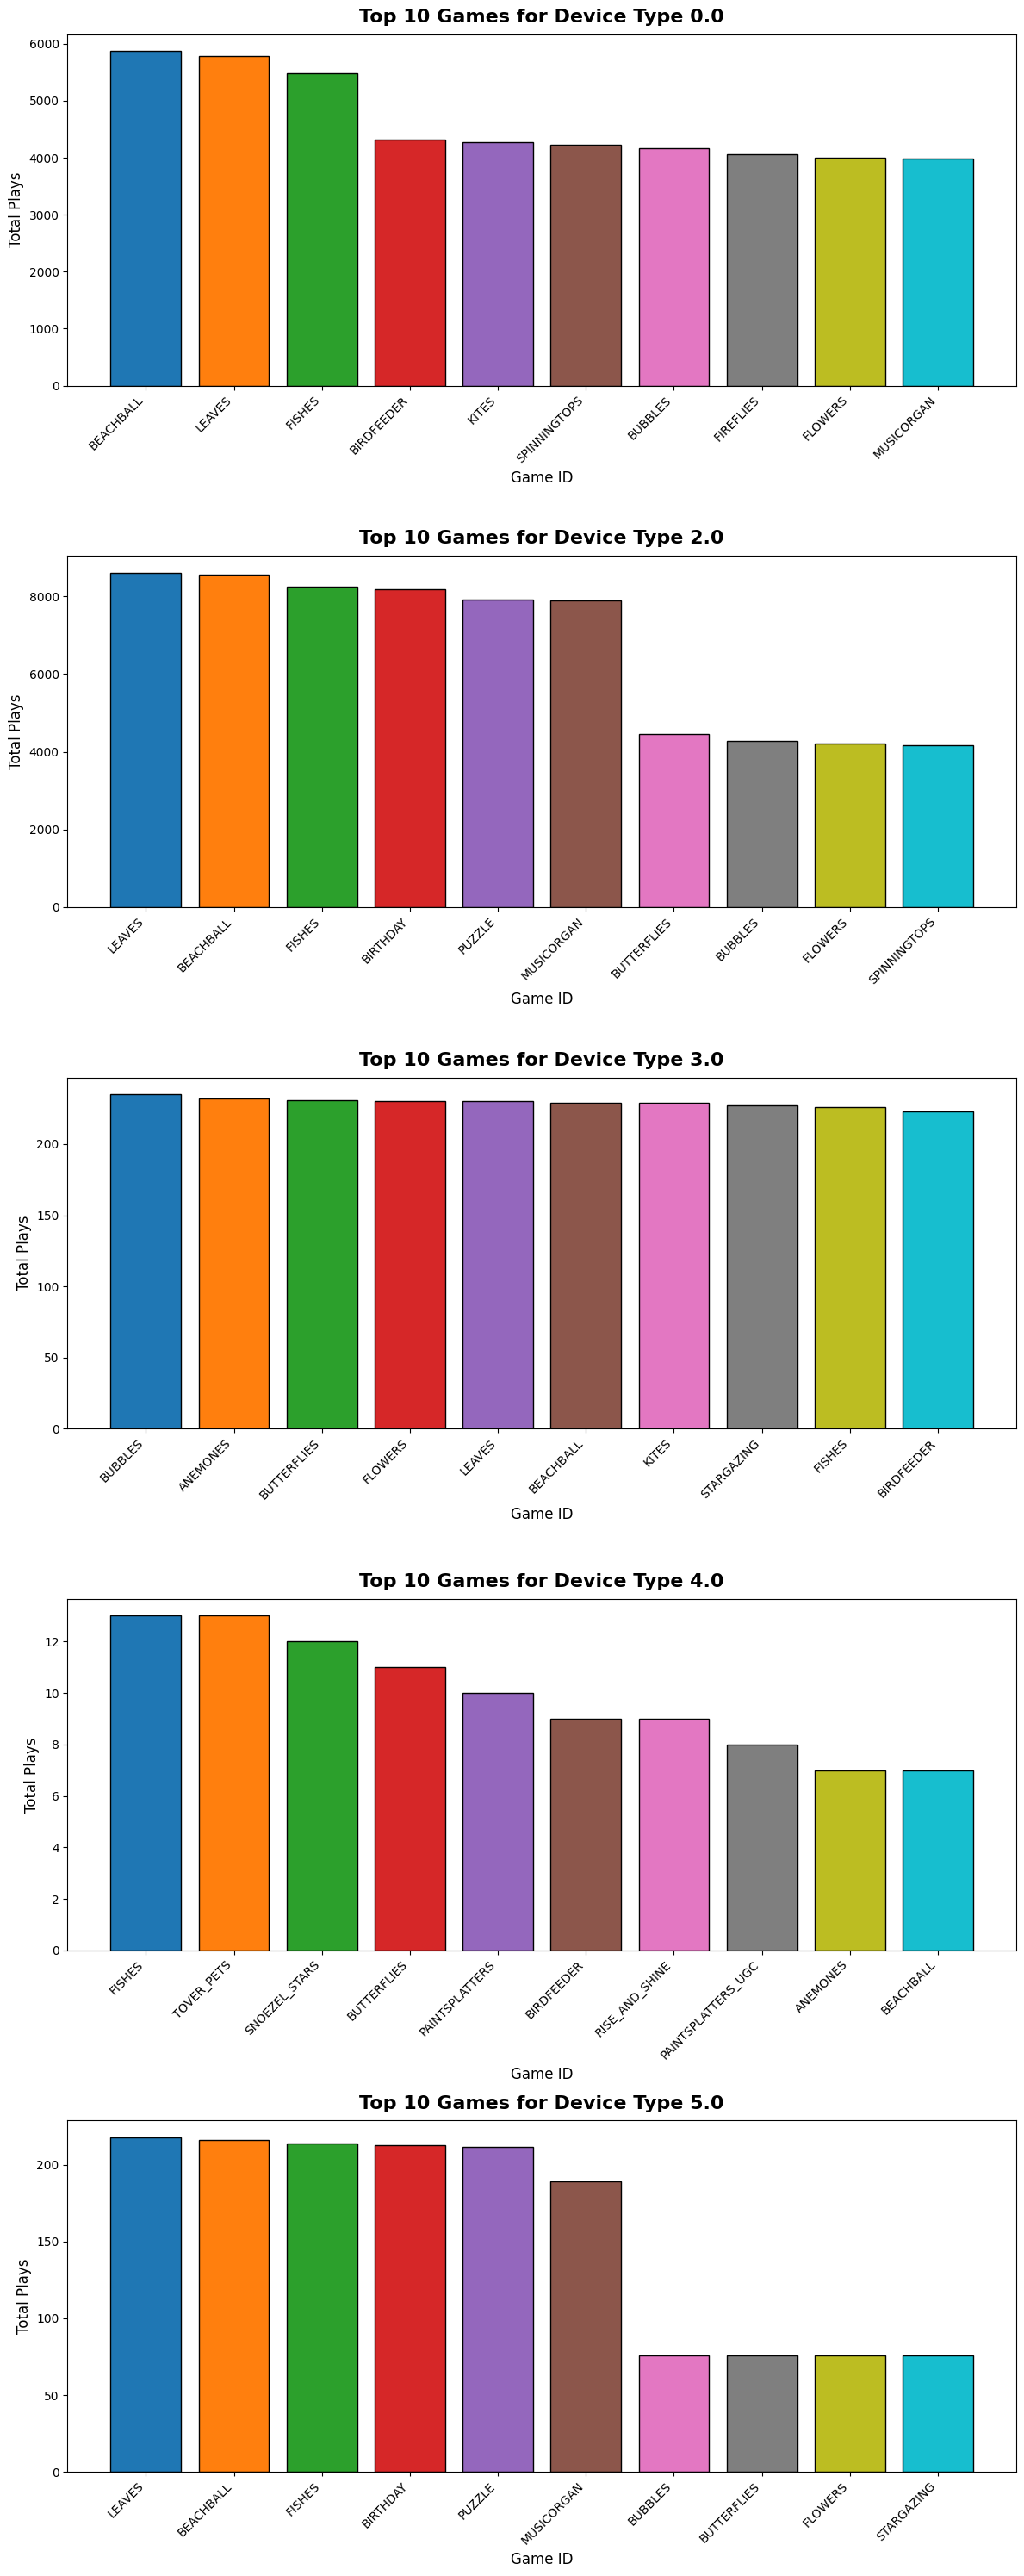

In [35]:
games_per_device = df_games.groupby(['device_type', 'generic_string']).size().reset_index(name='play_count')
games_per_device = games_per_device.sort_values(['device_type', 'play_count'], ascending=[True, False])

top_games_per_device = games_per_device.groupby('device_type').head(10)

unique_devices = top_games_per_device['device_type'].unique()

fig, axes = plt.subplots(nrows=len(unique_devices), ncols=1, figsize=(12, 6 * len(unique_devices)))

if len(unique_devices) == 1:
    axes = [axes]

colors = plt.cm.tab10.colors

for i, device in enumerate(unique_devices):
    device_data = top_games_per_device[top_games_per_device['device_type'] == device]
    axes[i].bar(device_data['generic_string'], device_data['play_count'], color=colors, edgecolor='black')
    axes[i].set_title(f'Top 10 Games for Device Type {device}', fontsize=16, fontweight='bold', pad=10)
    axes[i].set_xlabel('Game ID', fontsize=12)
    axes[i].set_ylabel('Total Plays', fontsize=12)
    axes[i].set_xticks(range(len(device_data['generic_string'])))
    axes[i].set_xticklabels(device_data['generic_string'], ha='right', rotation=45)

plt.tight_layout()
plt.show()

**<h4>Trends by country/region</h4>**

In [36]:
df_query['geoip.country_code'].value_counts()

geoip.country_code
US    270568
CA     70394
GB     61334
AU     59625
FR     42148
DE     26691
NL     17793
IE      8769
BE      1745
SE      1453
UK       690
CH       114
DK        67
NO        43
Name: count, dtype: int64

In [37]:
df_query['geoip.country_code'] = df_query['geoip.country_code'].replace('-', np.nan)
df_regions = df_query[df_query['geoip.country_code'].notnull()].value_counts().reset_index()

In [38]:
import country_converter as coco

df_regions['region'] = coco.convert(names=df_regions['geoip.country_code'], to='continent')

print(df_regions[['geoip.country_code', 'region']].value_counts())

geoip.country_code  region 
US                  America    120731
CA                  America     60509
GB                  Europe      51396
AU                  Oceania     37872
FR                  Europe      37802
NL                  Europe      16921
DE                  Europe      16374
IE                  Europe       8768
SE                  Europe       1334
BE                  Europe       1165
UK                  Europe        690
CH                  Europe        114
DK                  Europe         67
NO                  Europe         43
Name: count, dtype: int64


--- Total Unique Devices per Region ---
device_type    0.0    2.0   3.0   4.0   5.0
region                                     
America      103.0  158.0  13.0   1.0   0.0
Europe       120.0  395.0  29.0  22.0  13.0
Oceania       19.0   34.0   2.0   0.0   0.0


<Axes: title={'center': 'Device Types by Region'}, xlabel='region'>

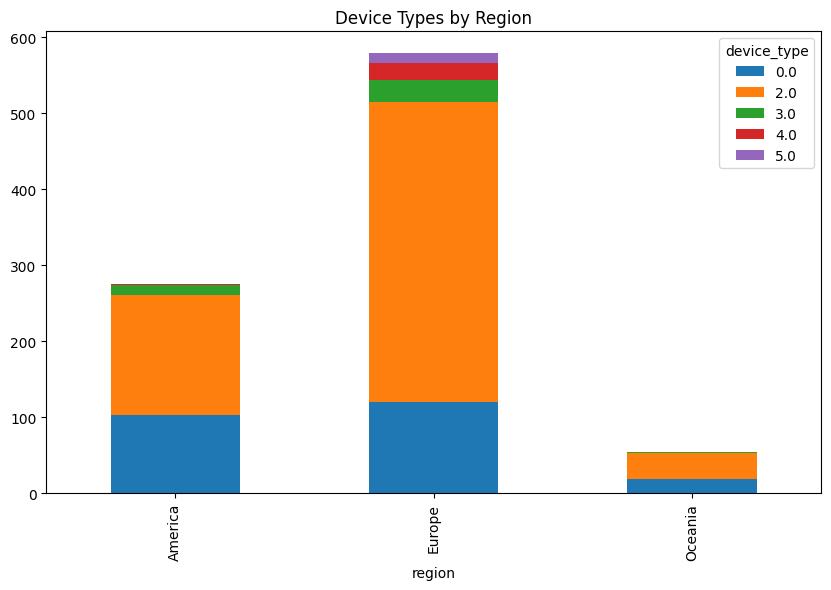

In [39]:
devices_per_region = df_regions.groupby(['region', 'device_type'])['hostname'].nunique().reset_index(name='device_count')

per_region_pivot = devices_per_region.pivot(index='region', columns='device_type', values='device_count').fillna(0)

print("--- Total Unique Devices per Region ---")
print(per_region_pivot.head(10))

per_region_pivot.head(10).plot(kind='bar', stacked=True, figsize=(10,6), title="Device Types by Region")

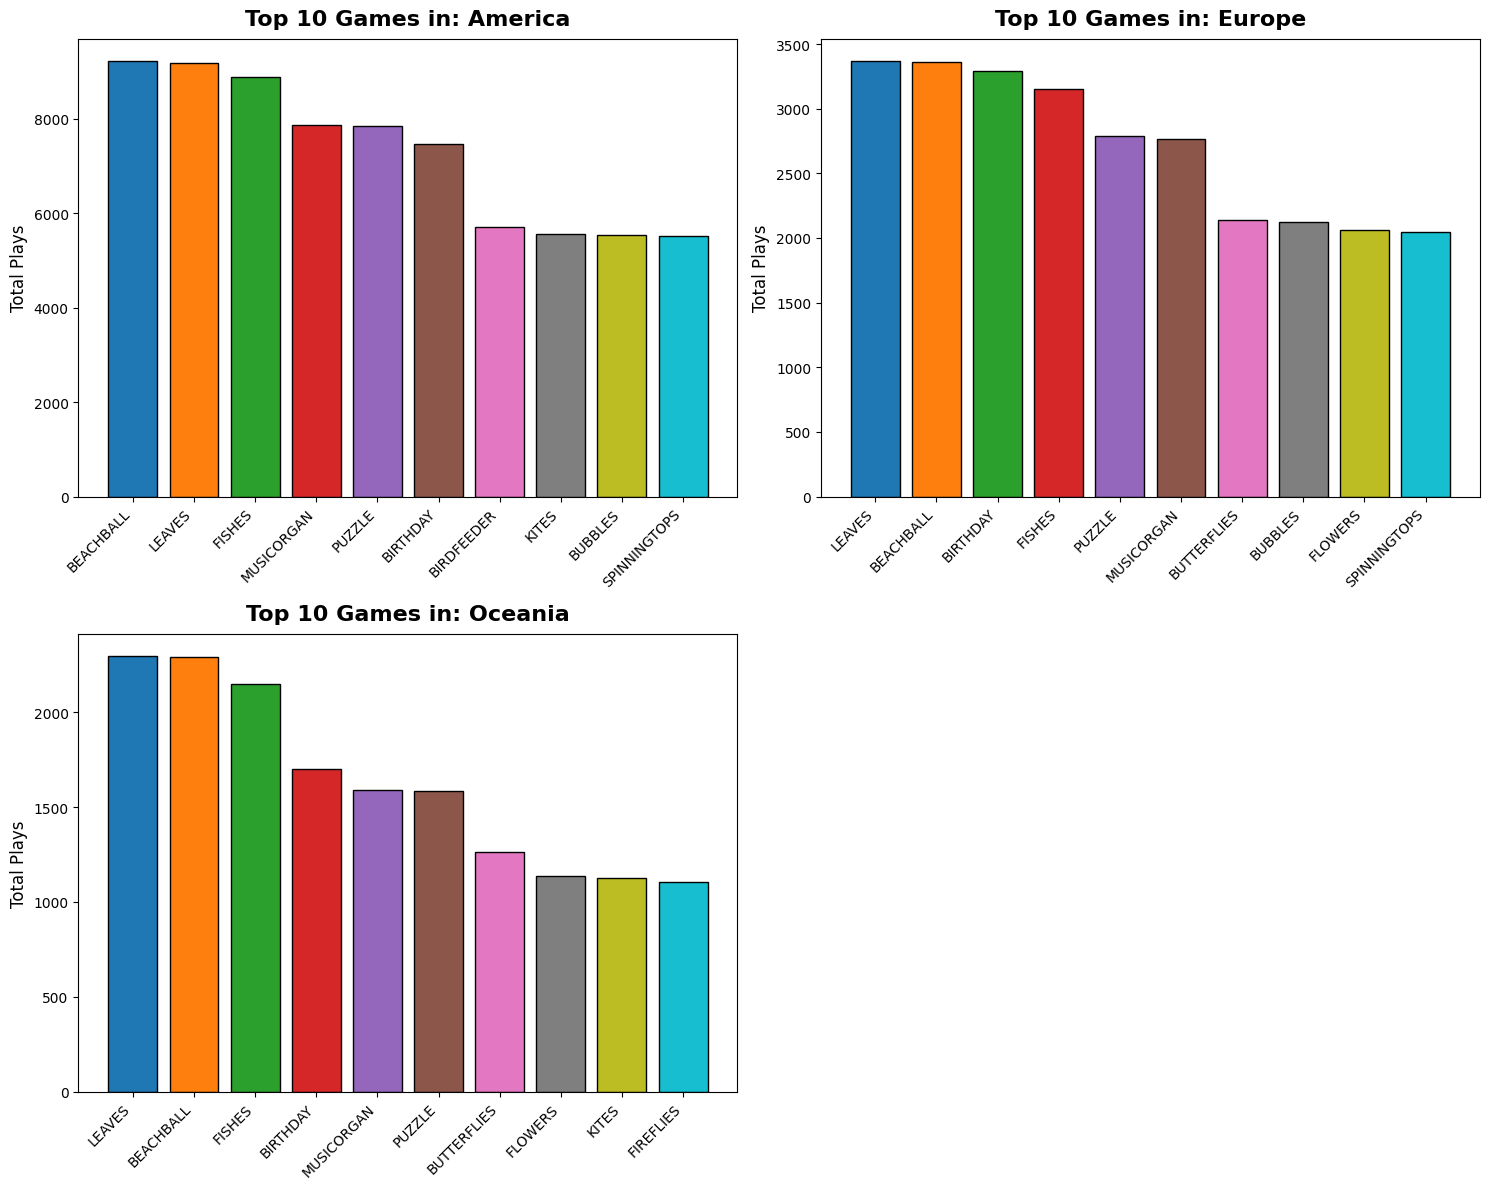

In [40]:
df_games = df_games[df_games['geoip.country_code']!='-'].copy()

df_games['region'] = coco.convert(names=df_games['geoip.country_code'], to='continent')
region_games = df_games.groupby(['region', 'generic_string']).size().reset_index(name='play_count')
region_games = region_games.sort_values(['region', 'play_count'], ascending=[True, False])

top_10_per_region = region_games.groupby('region').head(10)
unique_regions = top_10_per_region['region'].unique()

cols = 2
rows = math.ceil(len(unique_regions) / cols)
fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(15, 6 * rows))
axes = axes.flatten()

for i, region in enumerate(unique_regions):
    region_data = top_10_per_region[top_10_per_region['region'] == region]
    
    axes[i].bar(region_data['generic_string'], region_data['play_count'], color=colors, edgecolor='black')
    axes[i].set_title(f'Top 10 Games in: {region}', fontsize=16, fontweight='bold', pad=10)
    axes[i].set_ylabel('Total Plays', fontsize=12)
    axes[i].set_xticks(range(len(region_data['generic_string'])))
    axes[i].set_xticklabels(region_data['generic_string'], ha='right', rotation=45)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

--- Total Unique Devices per Country ---
device_type          0.0    2.0   3.0   4.0   5.0
geoip.country_code                               
AU                  19.0   34.0   2.0   0.0   0.0
BE                   1.0   11.0   0.0   0.0   0.0
CA                  26.0   55.0   0.0   0.0   0.0
CH                   1.0    4.0   0.0   0.0   0.0
DE                  16.0   79.0   4.0   0.0   0.0
DK                   0.0    1.0   0.0   0.0   0.0
FR                  50.0  162.0  14.0   6.0   0.0
GB                  28.0   66.0   2.0  11.0   1.0
IE                   3.0   12.0   1.0   0.0   0.0
NL                  18.0   46.0   7.0   3.0  13.0


<Axes: title={'center': 'Device Types by Country'}, xlabel='geoip.country_code'>

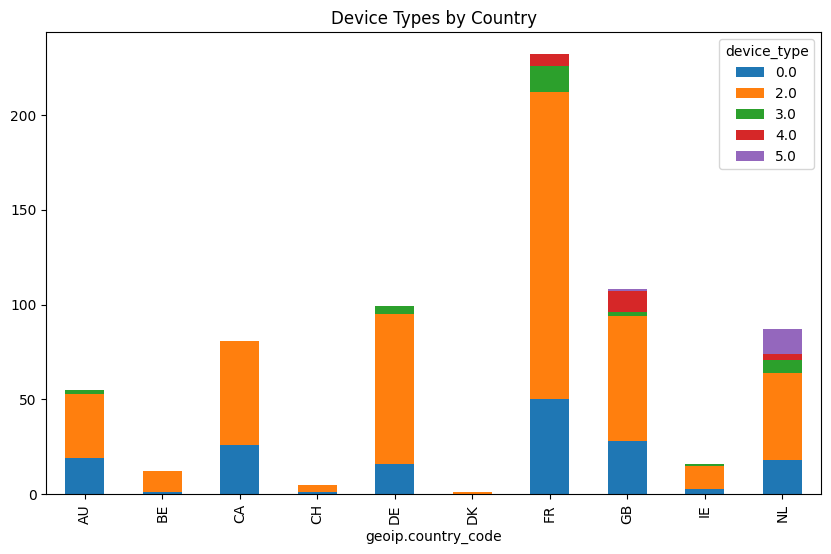

In [41]:
devices_per_country = df_regions.groupby(['geoip.country_code', 'device_type'])['hostname'].nunique().reset_index(name='device_count')

device_pivot = devices_per_country.pivot(index='geoip.country_code', columns='device_type', values='device_count').fillna(0)

print("--- Total Unique Devices per Country ---")
print(device_pivot.head(10))

device_pivot.head(10).plot(kind='bar', stacked=True, figsize=(10,6), title="Device Types by Country")

In [42]:
country_games = df_games.groupby(['geoip.country_code', 'generic_string']).size().reset_index(name='play_count')
country_games = country_games.sort_values(['geoip.country_code', 'play_count'], ascending=[True, False])

top_5_per_country = country_games.groupby('geoip.country_code').head(5)

print("--- Top 5 Games per Country ---")
print(top_5_per_country)

--- Top 5 Games per Country ---
     geoip.country_code generic_string  play_count
48                   AU         LEAVES        2297
8                    AU      BEACHBALL        2289
37                   AU         FISHES        2150
12                   AU       BIRTHDAY        1699
58                   AU     MUSICORGAN        1592
...                 ...            ...         ...
1135                 US      BEACHBALL        6546
1175                 US         LEAVES        6511
1165                 US         FISHES        6211
1198                 US         PUZZLE        5294
1186                 US     MUSICORGAN        5241

[70 rows x 3 columns]


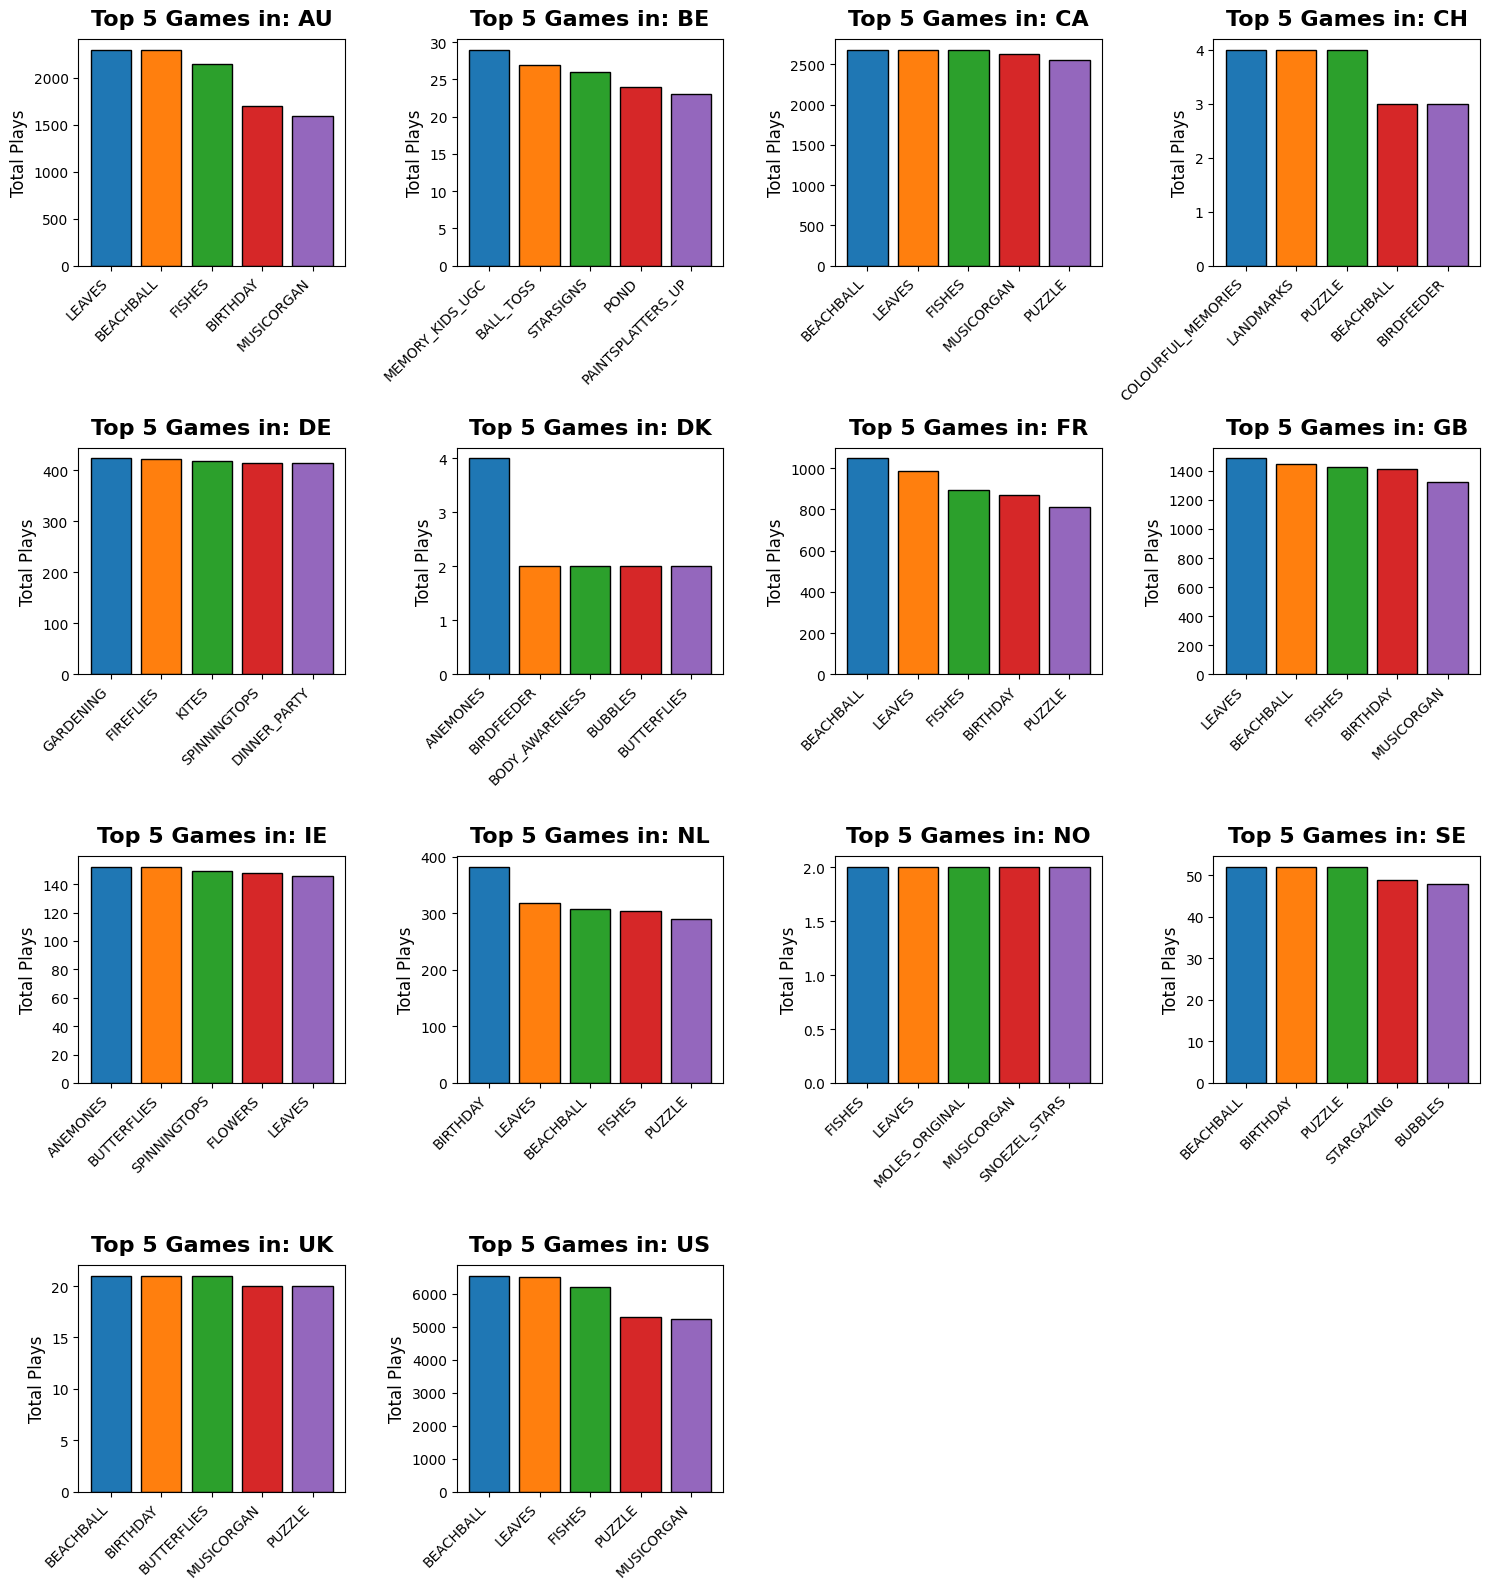

In [43]:
unique_countries = top_5_per_country['geoip.country_code'].unique()
cols = 4
rows = math.ceil(len(unique_countries) / cols)
fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(15, 4 * rows))
axes = axes.flatten()

for i, country in enumerate(unique_countries):
    country_data = top_5_per_country[top_5_per_country['geoip.country_code'] == country]
    
    axes[i].bar(country_data['generic_string'], country_data['play_count'], color=colors, edgecolor='black')
    axes[i].set_title(f'Top 5 Games in: {country}', fontsize=16, fontweight='bold', pad=10)
    axes[i].set_ylabel('Total Plays', fontsize=12)
    axes[i].set_xticks(range(len(country_data['generic_string'])))
    axes[i].set_xticklabels(country_data['generic_string'], ha='right', rotation=45)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [ ]:
# Hourly play pattern for the 5 most played games
top5_games = global_stats.nlargest(5, 'total_launches')['generic_string'].tolist()

game_hourly_df = (
    df_games[df_games['generic_string'].isin(top5_games)]
    .groupby(['generic_string', 'local_hour'])
    .size()
    .reset_index(name='plays')
)

fig, axes = plt.subplots(1, len(top5_games), figsize=(18, 4), sharey=False)
for i, game in enumerate(top5_games):
    data = game_hourly_df[game_hourly_df['generic_string'] == game].set_index('local_hour')['plays']
    data = data.reindex(range(24), fill_value=0)
    axes[i].bar(range(24), data.values, color='mediumseagreen', edgecolor='black', alpha=0.85)
    axes[i].set_title(game.replace('_', ' '), fontsize=10, fontweight='bold')
    axes[i].set_xticks([0, 6, 12, 18, 23])
    axes[i].set_xticklabels(['00', '06', '12', '18', '23'])
    axes[i].grid(axis='y', linestyle='--', alpha=0.4)

axes[0].set_ylabel('Plays')
plt.suptitle('Hourly Play Pattern — Top 5 Most Played Games (local time)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Country breakdown for the 8 most played games
top8_games = global_stats.nlargest(8, 'total_launches')['generic_string'].tolist()

game_country_df = (
    df_games[
        df_games['generic_string'].isin(top8_games) &
        (df_games['geoip.country_code'] != '-') &
        df_games['geoip.country_code'].notna()
    ]
    .groupby(['generic_string', 'geoip.country_code'])
    .size()
    .reset_index(name='plays')
    .sort_values(['generic_string', 'plays'], ascending=[True, False])
)

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, game in enumerate(top8_games):
    data = game_country_df[game_country_df['generic_string'] == game].head(10)
    axes[i].barh(data['geoip.country_code'], data['plays'], color='steelblue', alpha=0.85)
    axes[i].invert_yaxis()
    axes[i].set_title(game.replace('_', ' '), fontsize=10, fontweight='bold')
    axes[i].grid(axis='x', linestyle='--', alpha=0.4)

plt.suptitle('Country Breakdown — Top 8 Most Played Games', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# Scatter plot: session duration vs popularity for all games (≥5 sessions)
stats_plot = global_stats[global_stats['total_launches'] >= 5].copy()
fig, ax = plt.subplots(figsize=(14, 8))
ax.scatter(stats_plot['avg_duration'], stats_plot['total_launches'],
           color='#F4611C', alpha=0.7, s=80, edgecolors='white', linewidth=0.5, zorder=3)
for _, row in stats_plot.iterrows():
    if row['total_launches'] >= 3000 or row['avg_duration'] >= 9.0:
        ax.annotate(row['generic_string'].replace('_', ' '), (row['avg_duration'], row['total_launches']),
                    fontsize=7.5, ha='left', va='bottom', xytext=(4, 4), textcoords='offset points')
mean_dur = stats_plot['avg_duration'].mean()
mean_launches = stats_plot['total_launches'].mean()
ax.axvline(x=mean_dur, color='grey', linestyle='--', alpha=0.5, label=f'Mean duration: {mean_dur:.1f} min')
ax.axhline(y=mean_launches, color='grey', linestyle=':', alpha=0.5, label=f'Mean launches: {mean_launches:.0f}')
ax.legend(fontsize=9)
ax.set_xlabel('Average Session Duration (minutes)', fontsize=12, fontweight='bold')
ax.set_ylabel('Total Sessions Launched', fontsize=12, fontweight='bold')
ax.set_title('Session Duration vs Popularity — All Games (≥5 sessions)', fontsize=14, fontweight='bold', pad=15)
ax.grid(True, linestyle='--', alpha=0.4, zorder=1)
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

In [ ]:
# Scatter plot: session duration vs popularity for all games (≥5 sessions)
stats_plot = global_stats[global_stats['total_launches'] >= 5].copy()
fig, ax = plt.subplots(figsize=(14, 8))
ax.scatter(stats_plot['avg_duration'], stats_plot['total_launches'],
           color='#F4611C', alpha=0.7, s=80, edgecolors='white', linewidth=0.5, zorder=3)
for _, row in stats_plot.iterrows():
    if row['total_launches'] >= 3000 or row['avg_duration'] >= 9.0:
        ax.annotate(row['generic_string'].replace('_', ' '), (row['avg_duration'], row['total_launches']),
                    fontsize=7.5, ha='left', va='bottom', xytext=(4, 4), textcoords='offset points')
mean_dur = stats_plot['avg_duration'].mean()
mean_launches = stats_plot['total_launches'].mean()
ax.axvline(x=mean_dur, color='grey', linestyle='--', alpha=0.5, label=f'Mean duration: {mean_dur:.1f} min')
ax.axhline(y=mean_launches, color='grey', linestyle=':', alpha=0.5, label=f'Mean launches: {mean_launches:.0f}')
ax.legend(fontsize=9)
ax.set_xlabel('Average Session Duration (minutes)', fontsize=12, fontweight='bold')
ax.set_ylabel('Total Sessions Launched', fontsize=12, fontweight='bold')
ax.set_title('Session Duration vs Popularity — All Games (≥5 sessions)', fontsize=14, fontweight='bold', pad=15)
ax.grid(True, linestyle='--', alpha=0.4, zorder=1)
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

In [ ]:
# All games with ≥5 sessions — complete stats sorted by avg session duration
all_game_stats = (
    global_stats[global_stats['total_launches'] >= 5]
    .copy()
    .sort_values('avg_duration', ascending=False)
    .reset_index(drop=True)
)
all_game_stats['avg_duration'] = all_game_stats['avg_duration'].round(2)
all_game_stats['total_duration'] = all_game_stats['total_duration'].round(1)
all_game_stats.index += 1
all_game_stats.columns = ['Game', 'Total Launches', 'Avg Duration (min)', 'Total Duration (min)']
display(all_game_stats)